# Two Kinds of Databases

Alex Ronczewski  
2026-07-29

## Outline

### Prerequisites

-   Notebook 6 of this stream: transactions, indexes, and row versus
    column storage.

### Learning Outcomes

By the end of this notebook you will be able to:

1.  Explain **OLTP** and **OLAP** workloads, and why one database serves
    both poorly.
2.  Design a **star schema**: a fact table at a set grain, with
    dimension tables around it.
3.  Write an **ETL** script that moves data from the transactional
    system into the warehouse.
4.  Pull a model-ready table from the warehouse, and check an OLS
    regression against the truths we built into the data.
5.  Understand **warehouses** and **data lakes** against what we already
    learned, and say how ML systems feed from them.

## 1. Where we are in the stream

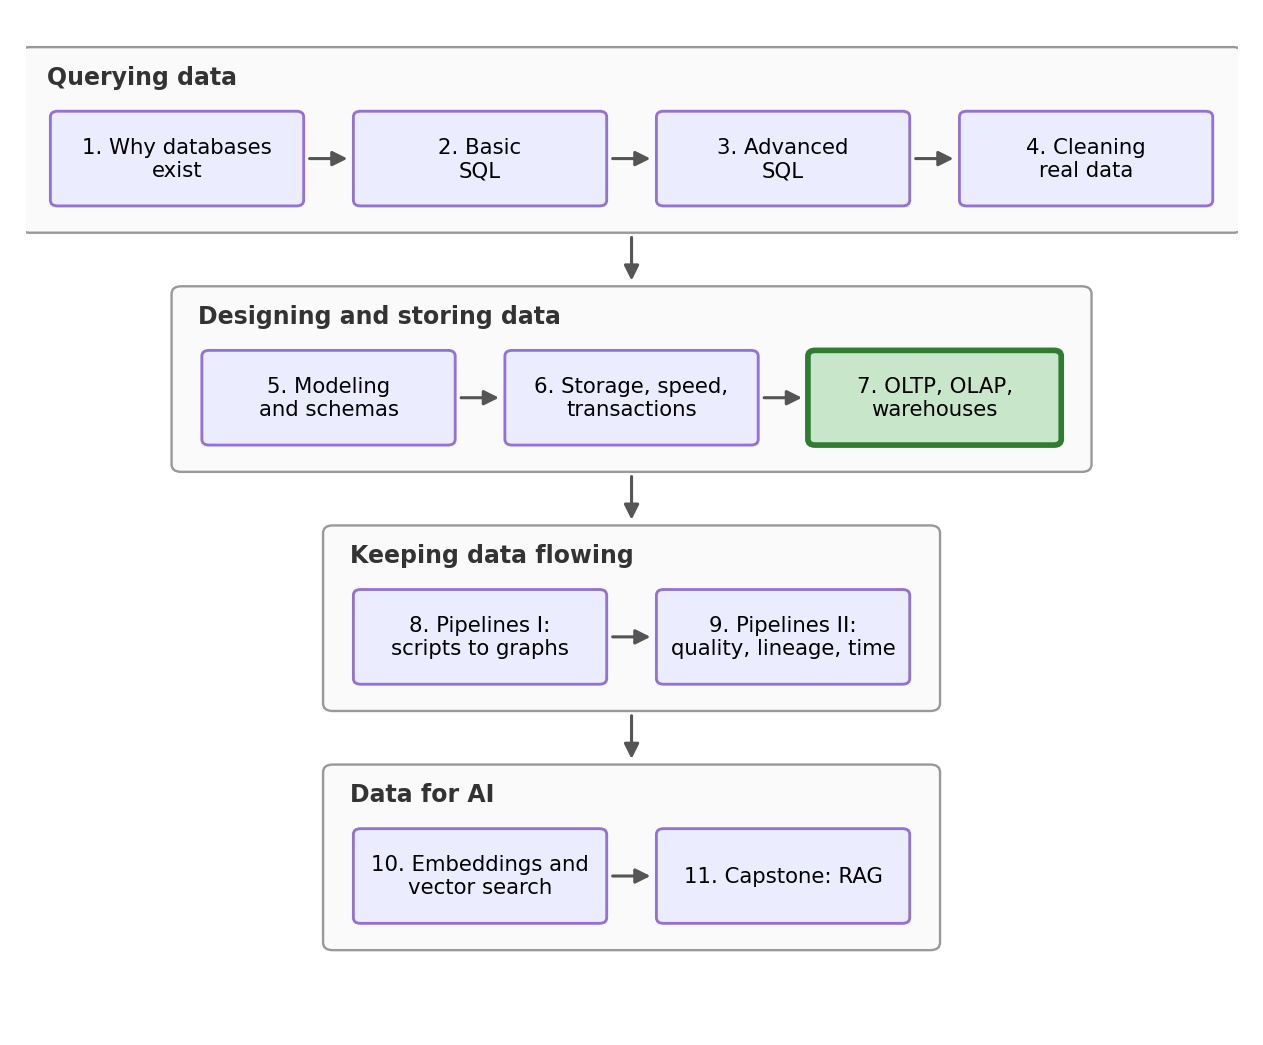

Wave 2 of our survey launched in September. The office has been extra
busy since. The intake software has been writing interviews into
Notebook 5’s schema for months, the crash test and the index from
Notebook 6 succeeded and saved us a couple of times, and everyone was
happy for a while. Then two emails arrived on the same morning.

> **The freeze report, from the survey office.** “Since the research
> team got access, the intake app freezes for seconds at a time, always
> in the afternoon. Interviewers are sitting there watching a spinner
> while a respondent waits on the line. We think it’s your colleagues’
> queries. Can they please stop?”

> **The plea, from the research lead.** “The office wants us off the
> live system, which is rich coming from them, because querying it is
> miserable anyway: every question takes three joins and over a second,
> and that is today, at a quarter million rows. We need somewhere to
> actually work. Can we have our own database?”

Both emails are right, and they are describing the same core issue, just
from different perspectives. This notebook is about why the conflicting
points are built directly into the architecture, and about the standard
industry answer: give the analysts their own database, made specifically
for reading, and copy the data across on a schedule.

## 2. Two kinds of questions

The survey intake app asks tiny questions constantly: save this
response, show me this respondent’s history. Each one reads only a
handful of rows, needs every column of them, and must finish instantly
without ever losing data. The research side asks enormous questions but
far less frequently: average wage by region and month over two years.
Each one touches every row in the database, needs two or three columns
of them, and nobody minds if it takes a bit to run, as long as it does
not take the intake down with it.

The industry names for these two workloads are **OLTP**, online
transaction processing, and **OLAP**, online analytical processing. The
same split appears everywhere data lives. For example a university’s
registration system is OLTP: thousands of students each writing one
enrolment row that must never be lost or have an error. The dean’s
enrolment-trends report is OLAP: something like GPA averages for
Economics over the last 20 years. A bank’s card terminal is OLTP; its
fraud-pattern analysis is OLAP.

|                 | Transactional (OLTP)                      | Analytical (OLAP)                 |
|------------------------|------------------------|------------------------|
| Who is asking   | the intake app, hundreds of times an hour | a few analysts, a few times a day |
| A typical job   | save one response, fetch one history      | summarize two years of everything |
| Rows touched    | a few                                     | all of them                       |
| Columns touched | all of them                               | two or three                      |
| What good means | instant, and never loses a row            | scans fast                        |

Notebook 5 taught that writers need normalization: one fact in one
place, so an update cannot half-happen. Notebook 6 taught that readers
want columns: scan only what the question names. Both lessons are
correct, and in those lessons we showed different databases with
different engines. One database cannot be both shapes at once.

## 3. Survey Wave 2

To show the issue and its fix, we need to remake the live system. So we
simulate it: the wave 2 operational database, exactly as the intake
software would have built it, with two new years of data. We take full
advantage of being the simulator. The wages will not be random noise; we
will write some economic concepts into them, education and union
premiums, an age gradient, a wage trend, with values we choose. At the
end of the notebook a regression gets to rediscover them, and because we
placed the values into the data, we can accurately grade how well the
regression did.

In [1]:
import os
import time
import sqlite3
import duckdb
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt

First, the lookup table, and it is Notebook 2’s `provinces.csv` plus the
Saskatchewan row that Notebook 5 discovered was missing, this time
appended in `pandas` (`.loc[len(...)]` writes one new row onto the end
of a dataframe):

In [2]:
provinces_df = pd.read_csv("datasets/provinces.csv")
provinces_df.loc[len(provinces_df)] = ["Saskatchewan", "Prairies", 15.00, 1253569]
provinces_df

Now 60,000 respondents, generated with the same method as Notebook 6:

In [3]:
rng = np.random.default_rng(42)
n_people = 60_000

respondents = pd.DataFrame({
    "respondent_id": np.arange(1, n_people + 1),
    "age": rng.integers(19, 66, n_people),
    "gender": rng.choice(["Woman", "Man", "Nonbinary"], n_people, p=[0.48, 0.48, 0.04]),
    "education": rng.choice(["High school", "College diploma", "Bachelor's degree", "Graduate degree"],
                            n_people, p=[0.30, 0.25, 0.30, 0.15]),
    "union_member": rng.integers(0, 2, n_people),
    "industry": rng.choice(["Construction", "Education", "Finance", "Health care", "Hospitality",
                            "Manufacturing", "Public administration", "Retail", "Technology"], n_people),
    "province": rng.choice(provinces_df["province"], n_people,
                           p=provinces_df["population"] / provinces_df["population"].sum()),
})
respondents.head()

And 250,000 interview responses over two years, where we add a wage
formula. The constants at the top are the sample truths of this
fictitious world: finishing college adds 10 log points to your wage, a
bachelor’s 25, a graduate degree 40, union membership 12, every year of
age 0.4, and the whole labour market drifts up 3 percent a year. The
dates are a fixed launch day plus `pd.to_timedelta` random days. This is
the whole reason the stream simulates its data: the teaching requires
knowing the truth. We know this world’s truths because we wrote them, so
the end of this notebook can check whether the warehouse gives them
back. Real data comes with no answer key. Keep these numbers in mind;
they come back at the end.

In [4]:
# Below are the constants of our simulated world
EDUCATION_PREMIUM = {"High school": 0.00, "College diploma": 0.10, "Bachelor's degree": 0.25, "Graduate degree": 0.40}
UNION_PREMIUM = 0.12
AGE_PREMIUM = 0.004
ANNUAL_GROWTH = 0.03

n_resp = 250_000
responses = pd.DataFrame({
    "response_id": np.arange(1, n_resp + 1),
    "respondent_id": rng.integers(1, n_people + 1, n_resp),
    "interview_date": pd.Timestamp("2026-09-01") + pd.to_timedelta(rng.integers(0, 730, n_resp), unit="D"),
    "weekly_hours": rng.normal(37, 6, n_resp).clip(5, 80).round(1),
})

traits = responses.merge(respondents, on="respondent_id")
years_in = (traits["interview_date"] - pd.Timestamp("2026-09-01")).dt.days / 365

log_wage = (3.2
            + traits["education"].map(EDUCATION_PREMIUM)
            + UNION_PREMIUM * traits["union_member"]
            + AGE_PREMIUM * traits["age"]
            + ANNUAL_GROWTH * years_in
            + rng.normal(0, 0.25, n_resp))

responses["hourly_wage"] = np.exp(log_wage).clip(17.40, None).round(2)
print(f"mean wage = {responses['hourly_wage'].mean():.2f}")

mean wage = 38.99

A mean wage of 39.00, similar to every accurate wage this stream has
produced. The wage was *produced* by education, union status and age,
but the response table does not *store* those columns. They live once,
on the respondent. That is Notebook 5’s normalization working correctly,
and it is also exactly why the analysts will need joins.

The office built the intake database on Notebook 5’s design, so we
recreate it faithfully: keys, constraints, `STRICT`, Notebook 5’s
foreign-key pragma for the connection, and Notebook 6’s index on the
column the app searches all day. In the next cell we re-create the
schema.

In [5]:
op = sqlite3.connect("datasets/wage_wave2.db")
op.execute("PRAGMA foreign_keys = ON")

op.execute("DROP TABLE IF EXISTS response")
op.execute("DROP TABLE IF EXISTS respondent")
op.execute("DROP TABLE IF EXISTS province")
op.execute("""CREATE TABLE province (
    province      TEXT    PRIMARY KEY,
    region        TEXT    NOT NULL,
    minimum_wage  REAL    NOT NULL CHECK (minimum_wage > 0),
    population    INTEGER NOT NULL CHECK (population > 0)) STRICT""")
op.execute("""CREATE TABLE respondent (
    respondent_id INTEGER PRIMARY KEY,
    age           INTEGER NOT NULL CHECK (age BETWEEN 15 AND 100),
    gender        TEXT    NOT NULL,
    education     TEXT    NOT NULL,
    union_member  INTEGER NOT NULL CHECK (union_member IN (0, 1)),
    industry      TEXT    NOT NULL,
    province      TEXT    NOT NULL REFERENCES province(province)) STRICT""")
op.execute("""CREATE TABLE response (
    response_id   INTEGER PRIMARY KEY,
    respondent_id INTEGER NOT NULL REFERENCES respondent(respondent_id),
    interview_date TEXT   NOT NULL,
    weekly_hours  REAL    NOT NULL CHECK (weekly_hours BETWEEN 0 AND 100),
    hourly_wage   REAL    NOT NULL CHECK (hourly_wage > 0)) STRICT""")
op.execute("CREATE INDEX idx_response_respondent ON response(respondent_id)")

Here we place the data into the database which has the schema.

In [6]:
provinces_df.to_sql("province", op, index=False, if_exists="append")
respondents.to_sql("respondent", op, index=False, if_exists="append")

for_op = responses.copy()
for_op["interview_date"] = for_op["interview_date"].dt.strftime("%Y-%m-%d")
for_op.to_sql("response", op, index=False, if_exists="append")

pd.read_sql("""SELECT (SELECT COUNT(*) FROM province) AS provinces,
                      (SELECT COUNT(*) FROM respondent) AS respondents,
                      (SELECT COUNT(*) FROM response) AS responses""", op)

6 provinces, 60,000 respondents, 250,000 responses. Watch the system do
the job it was designed for. Respondent 55585 is the simulation’s most
common participant, with a whole 15 interviews:

In [7]:
start = time.perf_counter()
history = pd.read_sql("SELECT * FROM response WHERE respondent_id = 55585", op)
print(f"{1000 * (time.perf_counter() - start):.1f} ms to fetch {len(history)} rows")

1.1 ms to fetch 15 rows

About a millisecond, thanks to the index. Writes are just as
comfortable. The `intake` connection below stands in for the intake
software itself, autocommitting like Notebook 6’s manual connection so
each saved response never gets deleted, and with one new setting:
`timeout=0.5` tells it to give up after half a second of waiting instead
of the default five, which will matter shortly.

In [8]:
intake = sqlite3.connect("datasets/wage_wave2.db", isolation_level=None, timeout=0.5)
intake.execute("PRAGMA foreign_keys = ON")

start = time.perf_counter()
intake.execute("INSERT INTO response VALUES (300000, 12345, '2028-09-01', 38.0, 41.50)")
print(f"one response saved in {1000 * (time.perf_counter() - start):.1f} ms")
intake.execute("DELETE FROM response WHERE response_id = 300000")

one response saved in 2.9 ms

Milliseconds to read, milliseconds to write. As an OLTP system, this
database is excellent. We have half of our solution fixed (at least so
it seems), the survey workers are happy for now. Now we add the
analysts.

## 4. Analysts

Here is the research team’s most common question, the regional briefing
from Notebook 2 has expanded a bit since we worked on it (as most
projects do): wages, response counts and union shares, by region and
month, pulled from everything. On the operational schema this question
costs three tables and two joins, because the facts it needs are
normalized apart, this is expected but let’s see how long it takes:

In [9]:
briefing = """SELECT p.region, strftime('%Y-%m', x.interview_date) AS month,
                     COUNT(*) AS responses,
                     ROUND(AVG(x.hourly_wage), 2) AS avg_wage,
                     ROUND(AVG(r.union_member), 3) AS union_share
              FROM response AS x
              JOIN respondent AS r ON x.respondent_id = r.respondent_id
              JOIN province AS p ON r.province = p.province
              GROUP BY p.region, month
              ORDER BY month, p.region"""

start = time.perf_counter()
briefing_table = pd.read_sql(briefing, op)
print(f"{time.perf_counter() - start:.1f} s for {len(briefing_table)} rows")
briefing_table.head(3)

1.2 s for 72 rows

Over a second, for one question, and the research lead runs dozens a day
on a table that doubles every two years (many proper databases are far
larger so imagine if this took a few minutes to run). Annoying for the
analyst; now watch what it does to everyone else. We play both sides at
once. The analyst starts the big read and gets partway through it:
`.execute` on a connection hands back a **cursor**, an object that walks
the results one row at a time, and `.fetchone()` takes a single row and
then stops, mid-scan, like an analyst whose laptop is chewing through
results:

In [10]:
analyst = sqlite3.connect("datasets/wage_wave2.db")
cursor = analyst.execute("SELECT * FROM response")
cursor.fetchone()

(1, 10673, '2026-11-24', 36.5, 29.88)

> **Predict first.** The analyst’s query is now mid-scan, holding the
> database’s read lock. At this exact moment, an interviewer finishes a
> call and the intake app tries to save the response. What happens?

In [11]:
intake.execute("INSERT INTO response VALUES (300001, 12345, '2028-09-01', 38.0, 41.50)")

`database is locked`. Notebook 6 taught that only one connection may
write at a time; this is the worst case scenario. While a reader is
inside the file, SQLite will not let a writer commit, so the intake app
waited its half-second and gave up, with a respondent on the line. The
freeze ends the moment the analyst’s query finishes:

In [12]:
cursor.fetchall()

start = time.perf_counter()
intake.execute("INSERT INTO response VALUES (300001, 12345, '2028-09-01', 38.0, 41.50)")
print(f"saved in {1000 * (time.perf_counter() - start):.1f} ms once the analyst finished")
intake.execute("DELETE FROM response WHERE response_id = 300001")

saved in 3.1 ms once the analyst finished

We reproduced the office’s afternoon freezes and the issue behind them.
Before anyone emails “just use a bigger database”: which on paper seems
like a fair response. We could just throw more compute at it and
hopefully it goes away. SQLite has a mode that lets readers and writers
coexist, and client-server systems like PostgreSQL handle concurrency
far more gracefully. But no setting removes the deeper conflicts. The
analyst’s scan still competes for the same disk, memory and cache the
intake needs. The analyst still pays two joins for every question,
because the data is shaped for writers. And every analyst with
production access is one `UPDATE` without a `WHERE` away from being a
common error from Notebook 3 (and a very awkward email). The workloads
want different shapes, different engines. So we give them exactly that.

## 5. The warehouse and the star

The analysts’ own database has a name: a **data warehouse**, a second
database that exists only to be read, rebuilt from the operational
system based off of scheduled updates. Nobody edits it by hand (Notebook
5). The warehouse is allowed to copy facts around for reading speed,
which is called **denormalization**, and doing it produces the most
widely used design in analytics: the **star schema**.

A star schema sorts every column possible into one of two piles. The
**fact table** sits in the middle and holds measurements, the numbers
you aggregate: wages, hours, one row per event. **Dimension tables** sit
around it and hold descriptions, the words you group by: who, where,
when (people, countries, time, postal codes). Every analytical question
in this stream has had the same skeleton, a number summarized by some
words (wage by province), and the star is that skeleton: words become
just one join away.

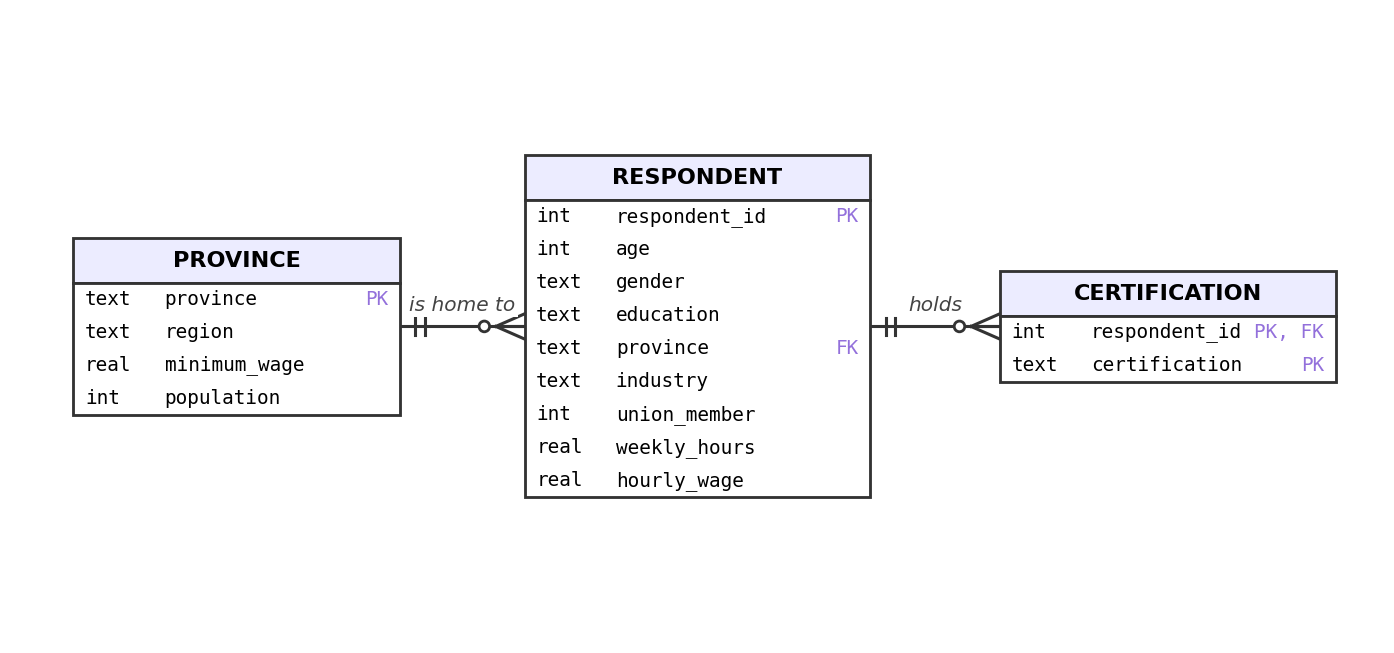

Two of these tables you can recognize: `dim_respondent` is the
respondent table from before, and `dim_province` is the lookup table
that we have been using since Notebook 2. `dim_date` is the new
warehouse idea: the calendar is data too. Storing every date’s year,
month and quarter once, in a table, means no query ever computes
`strftime` again; time becomes something you join to, and “by month” or
“by quarter” becomes a `GROUP BY` on a ready-made column.

> **A fact table states its grain**
>
> The first sentence of any warehouse design is the fact table’s grain:
> here, **one row per interview response**. Every measure in the table
> must be true at that grain, and every question answered from it
> inherits that grain. In notebook 2 we once averaged wages at the wrong
> grain, and Notebook 3 showed the gap this led to (45 cents), all
> without an error message; a star schema in a warehouse makes that
> mistake difficult to make, because the grain is not a convention
> someone remembers, it is the published shape of the central table.

The fact table also shows off denormalization: it carries `province`
even though the operational schema stores province on the respondent, so
that a by-region question does not have to route through
`dim_respondent`. And it carries `full_time`, a variable representing
Notebook 2’s 30-hour StatCan line, precomputed once instead of
re-derived inside every analyst’s `CASE` expression forever.

## 6. ETL: The Connection

We need something to build all that from the current live system, and
that something has a name you will see in almost every data job posting:
**ETL**, extract, transform, load. **Extract** copies the raw tables out
of the operational database, one pass, ideally at 3 a.m. when the intake
system is asleep. **Transform** reshapes them into the star: joins,
derived columns, renames, exactly the kind of work Notebooks 3 and 4
did, now standardized and scheduled. **Load** writes the result into the
warehouse. Here is each of those steps.

Extract:

In [13]:
raw_responses = pd.read_sql("SELECT * FROM response", op)
raw_respondents = pd.read_sql("SELECT * FROM respondent", op)
raw_provinces = pd.read_sql("SELECT * FROM province", op)

print(f"extracted {len(raw_responses):,} responses, {len(raw_respondents):,} respondents, {len(raw_provinces)} provinces")

extracted 250,000 responses, 60,000 respondents, 6 provinces

Transform. `pd.to_datetime` turns the stored ISO text back into real
dates so the `.dt` accessor can pull years, months and quarters out of
them; the merge stamps each response with its respondent’s province; and
the comparison builds the full-time dummy variable:

In [14]:
raw_responses["interview_date"] = pd.to_datetime(raw_responses["interview_date"])

fact = raw_responses.merge(raw_respondents[["respondent_id", "province"]], on="respondent_id")
fact["full_time"] = (fact["weekly_hours"] >= 30).astype(int)          # Notebook 2's 30-hour line; built as a 0/1 dummy variable
fact["date"] = fact["interview_date"].dt.strftime("%Y-%m-%d")
fact_response = fact[["response_id", "respondent_id", "province", "date",
                      "full_time", "weekly_hours", "hourly_wage"]]

dim_respondent = raw_respondents                                      # one row per person: already a dimension
dim_province = raw_provinces

dim_date = pd.DataFrame({"date": sorted(fact["date"].unique())})      # the calendar, stored once
dates = pd.to_datetime(dim_date["date"])
dim_date["year"] = dates.dt.year
dim_date["month"] = dates.dt.month
dim_date["year_month"] = dates.dt.strftime("%Y-%m")
dim_date["quarter"] = dates.dt.quarter

Load, into the engine Notebook 6 taught for this workload. Handing
`duckdb.connect` a filename gives the warehouse permanent space on disk,
the same way SQLite files work, and `CREATE OR REPLACE TABLE` is
`CREATE TABLE` that overwrites any previous version, so tonight’s run
replaces last night’s:

In [15]:
warehouse = duckdb.connect("datasets/wage_warehouse.duckdb")
warehouse.execute("CREATE OR REPLACE TABLE fact_response AS SELECT * FROM fact_response")
warehouse.execute("CREATE OR REPLACE TABLE dim_respondent AS SELECT * FROM dim_respondent")
warehouse.execute("CREATE OR REPLACE TABLE dim_province AS SELECT * FROM dim_province")
warehouse.execute("CREATE OR REPLACE TABLE dim_date AS SELECT * FROM dim_date")

warehouse.execute("""SELECT (SELECT COUNT(*) FROM fact_response) AS facts,
                            (SELECT COUNT(*) FROM dim_respondent) AS respondents,
                            (SELECT COUNT(*) FROM dim_province) AS provinces,
                            (SELECT COUNT(*) FROM dim_date) AS dates""").df()

A quarter million facts, three dimensions around them, and the whole
warehouse file is about 2 MB against the operational database’s 16, due
to column compression. Notebook 4 ended by pointing out that its
cleaning script was already a pipeline; this is a second one, and it
currently has one serious flaw we are choosing to ignore. It runs when
we run it, and it assumes it always finishes. What happens when a
scheduled ETL dies halfway through is the opening example of our next
notebook.

## 7. Analytics, unblocked

Let’s now compare the analyst’s perspective on this new warehouse model
with the star schema:

In [16]:
star_briefing = """SELECT p.region, d.year_month,
                          COUNT(*) AS responses,
                          ROUND(AVG(f.hourly_wage), 2) AS avg_wage,
                          ROUND(AVG(r.union_member), 3) AS union_share
                   FROM fact_response AS f
                   JOIN dim_respondent AS r ON f.respondent_id = r.respondent_id
                   JOIN dim_province AS p ON f.province = p.province
                   JOIN dim_date AS d ON f.date = d.date
                   GROUP BY p.region, d.year_month
                   ORDER BY d.year_month, p.region"""

start = time.perf_counter()
star_table = warehouse.execute(star_briefing).df()
print(f"{1000 * (time.perf_counter() - start):.0f} ms for {len(star_table)} rows")
star_table.head(3)

22 ms for 81 rows

Tens of milliseconds, tens of times faster here, the same 72 rows with
the same numbers. And notice the two less flashy improvements. The query
joins to purpose-built tables where month and region are ready-made
columns rather than expressions, and it runs on a machine the intake app
has never heard of. The analysts can work on this warehouse as much as
they want and nobody from the survey department is affected.

## 8. The warehouse feeds the model

The last stop for most warehouse data is not a chart; it is a model.
Every regression you have run in an econometrics course started from a
table that looked suspiciously clean, one row per observation, outcome
and regressors side by side. That table is a warehouse product, and now
we can manufacture it ourselves: one star query, with Notebook 2’s
`CASE` building the dummy variables on the way out.

In [17]:
model_data = warehouse.execute("""
    SELECT f.hourly_wage, r.age, r.union_member,
           CASE WHEN r.education = 'College diploma' THEN 1 ELSE 0 END AS college,
           CASE WHEN r.education = 'Bachelor''s degree' THEN 1 ELSE 0 END AS bachelor,
           CASE WHEN r.education = 'Graduate degree' THEN 1 ELSE 0 END AS graduate
    FROM fact_response AS f
    JOIN dim_respondent AS r ON f.respondent_id = r.respondent_id""").df()

model_data["log_wage"] = np.log(model_data["hourly_wage"])
model_data.head(3)

A quarter million rows, model-ready. `statsmodels` is Python’s standard
econometrics library, the one behind most regression output you have
seen in COMET, and its formula interface reads like R: outcome on the
left of the `~`, regressors on the right. We will run a regression on
log_wage with regressors for whether the person has a college,
bachelor’s, or graduate degree, whether they are a union member, and
their age.

In [18]:
fit = smf.ols("log_wage ~ college + bachelor + graduate + union_member + age", data=model_data).fit()

comparison = pd.DataFrame({
    "built_in": {"college": 0.10, "bachelor": 0.25, "graduate": 0.40, "union_member": 0.12, "age": 0.004},
    "estimated": fit.params.round(4),
}).reindex(["college", "bachelor", "graduate", "union_member", "age"])
comparison

We wrote a 0.10 college premium into the world; the regression, seeing
only the warehouse, reports 0.0981. Bachelor’s: 0.25 built in, 0.2482
found. Graduate: 0.40 and 0.3969. Union: 0.12 and 0.1202. Age: 0.004 and
0.0040. The intake system collected the facts, the ETL shaped them, the
warehouse served them, and the model at the end recovered the true
values from our fake world. When the numbers are real instead of
simulated, there are lots more resources to read like the [Causal ML
stream](https://ubcecon.github.io/praxis-ubc/docs/Causal_ML/notebook_01_prediction_inference_causality.html)
which begins exactly where this regression stops, with the question of
when a coefficient like 0.12 should have a causal reading.

## 9. Warehouses, lakes, and ML

If we take a step back from our two small files and made up example of a
survey company, you will see that we are looking at the standard
architecture of nearly every proper data-serious organization:

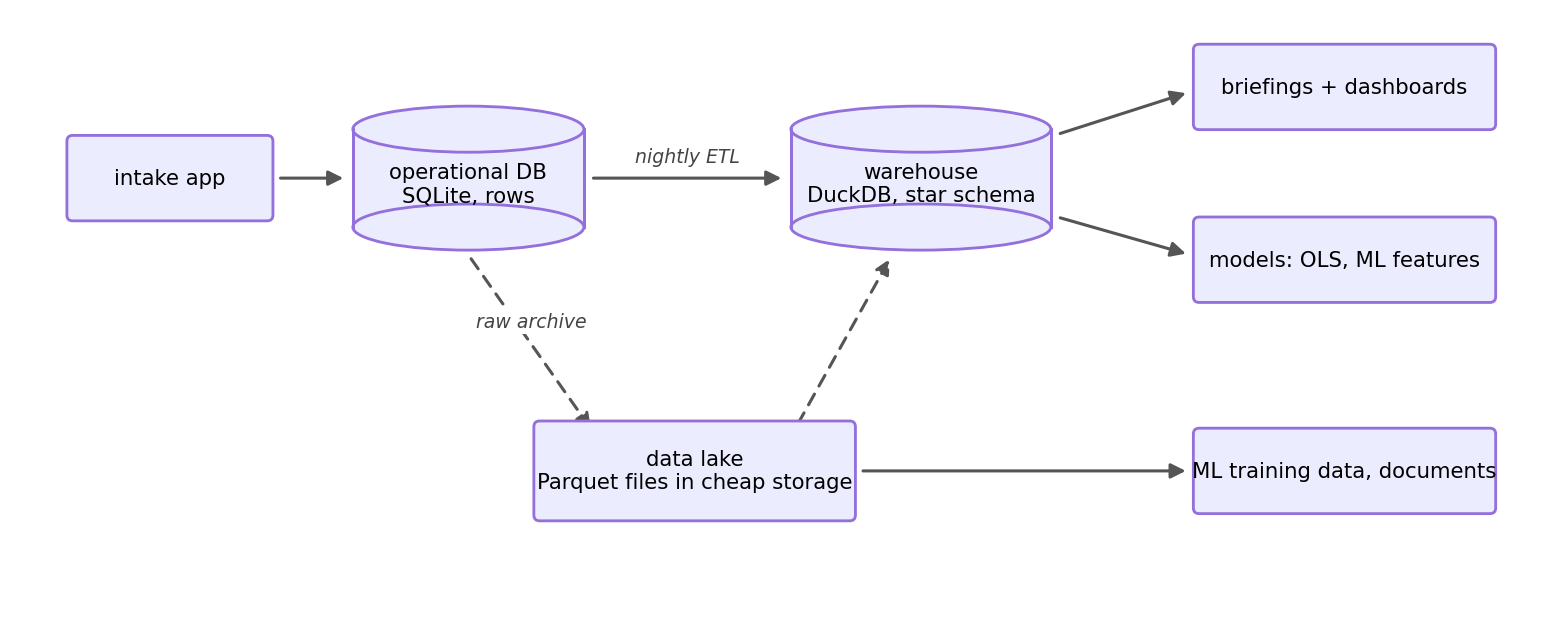

The one box we have not built is the **lake**, and Notebook 6 already
gave us its entire technology: Parquet files in cheap storage, queryable
where they lie. A warehouse is curated, star-shaped, and answers known
questions fast. A lake is the opposite: keep everything raw and cheap,
including data nobody has a schema for yet, logs, documents, images, and
impose structure later, when a question finally arrives. Archiving
tonight’s raw response extract to the lake, before any of our transforms
touched it, is one line:

In [19]:
raw_responses.to_parquet("datasets/response_archive.parquet")

warehouse.execute("SELECT COUNT(*) AS rows_in_the_lake FROM 'datasets/response_archive.parquet'").df()

Machine learning eats from both sides of this diagram. The features
behind a production fraud or churn model are warehouse queries,
aggregates per customer, refreshed on a schedule; teams industrialize
this with tools called feature stores, and underneath the branding they
are ETL into fact tables. The training corpus of a large language model
is the lake pattern at a huge, hard to even imagine, scale. Crawled
documents in cheap storage, filtered and deduplicated by pipelines. And
the RAG capstone this stream ends with is a small lake of documents, an
ETL that chunks and embeds them, and a retrieval query, which is why
Notebooks 10 and 11 will feel less like new material than like this
notebook just tailored to AI.

## 10. Conclusion

Two emails solved by one architecture and we are done for the day. The
intake system keeps its normalized rows, its transactions and its index,
and never sees an analyst again. The analysts get a warehouse: a star
schema in a columnar engine, rebuilt nightly by thirty lines of ETL.

The unresolved thread is the word “nightly”. Our ETL ran because we ran
it, top to bottom, and it worked because nothing went wrong. Real
pipelines run unattended, at 3 a.m., on data that arrives broken, on
machines that may die mid-way through. Making that safely function is
the entire third arc of this stream, and it starts with Notebook 8 doing
to our ETL what Notebook 6 did to the database: killing it halfway
through, on purpose, and seeing what happens.

> **You can now answer these interview questions**
>
> -   What is the difference between OLTP and OLAP, and why not serve
>     both from one database?
> -   What is a star schema? What belongs in the fact table, and what
>     makes a good dimension?
> -   What is ETL, and what kind of work belongs in the transform step?
> -   What is the difference between a data warehouse and a data lake?
>
> <details>
>
> <summary>
>
> Show / hide model answers
>
> </summary>
>
> -   OLTP is many tiny reads and writes that must be instant and never
>     lose data; OLAP is few enormous read-only scans. They want
>     different table shapes (normalized rows versus denormalized
>     columns), different engines, and isolation from each other, so
>     organizations run an operational database for the first and a
>     warehouse for the second, connected by ETL.
> -   A denormalized design for analytics: a central fact table holding
>     measures at one declared grain, joined to dimension tables holding
>     the descriptive attributes you filter and group by.
> -   Extract copies data out of source systems, transform reshapes it
>     (joins, derived columns, cleaning, conforming types), load writes
>     it into the warehouse. The transform step owns every derivation
>     that analysts would otherwise each redo: flags, calendar
>     attributes, standardized categories.
> -   A warehouse holds curated, schema-shaped tables built to answer
>     known questions fast. A lake holds raw files, cheap and often
>     without a schema, kept because storage is usually cheap; structure
>     gets imposed at read time, when a new question arrives.
>
> </details>

## Appendix: the modern database landscape

Everything in this stream runs on two in-process engines, chosen so that
nothing stands between you and the ideas. The same ideas ship under many
other names, and you now know what each of them mean:

| Engine                        | What it is                      | Where you will meet it                      |
|------------------------|------------------------|------------------------|
| SQLite                        | in-process OLTP, one file       | phones, browsers, apps, this stream         |
| PostgreSQL                    | client-server OLTP, open source | the default backend of the modern web       |
| MySQL / MariaDB               | client-server OLTP, open source | older web stacks, WordPress, legacy systems |
| SQL Server / Oracle           | client-server OLTP, commercial  | corporate and government back offices       |
| DuckDB                        | in-process OLAP, one file       | laptops-as-warehouses, this stream          |
| ClickHouse                    | client-server OLAP, open source | self-hosted analytics at scale              |
| BigQuery, Redshift, Snowflake | cloud warehouses                | the rented version of Notebook 7            |
| Databricks                    | cloud lakehouse                 | warehouse tooling on top of a Parquet lake  |

Two notes for the day a job hands you credentials to one of these.
First, you connect with a connection string, and its password belongs in
an environment variable, never typed into code, the same
separation-of-code-and-data instinct as Notebook 3’s `?` placeholders.
Second, BigQuery’s on-demand pricing bills by bytes scanned, which
converts Notebook 6’s lesson into money: `SELECT *` over a
petabyte-scale table is a real invoice. Snowflake and provisioned
Redshift bill by compute time instead, but scanning fewer columns still
means less I/O and a shorter, cheaper run, so naming your columns is no
longer just clean code, it saves money everywhere.

## Connections

-   **Back to [Notebook 5](notebook_05_designing_data.qmd) and [Notebook
    6](notebook_06_storage_speed_transactions.qmd):** normalization
    protects the writers, columns serve the readers, and this notebook
    stopped choosing between them by running both, with ETL as the
    bridge.
-   **Forward to [Notebook 8](notebook_08_pipelines_one.qmd):** our ETL
    ran perfectly because we babysat it and watched. Next, it runs
    unattended, dies halfway through, and double-counts everything on
    the retry, which is how idempotency, incremental loads and
    pipelines-as-graphs enter the stream.

### References

-   Codd, E. F., Codd, S. B., & Salley, C. T. (1993). *Providing OLAP to
    user-analysts: An IT mandate.* Codd & Associates. The white paper
    that coined OLAP, by the same Codd as Notebook 5’s relational model.
-   Kimball, R., & Ross, M. (2013). *The Data Warehouse Toolkit* (3rd
    ed.). Wiley. The book behind facts, dimensions, grain, and every
    star schema in industry.
-   Kleppmann, M. (2017). *Designing Data-Intensive Applications.*
    O’Reilly. Chapter 3’s second half is the OLTP/OLAP split and column
    storage.
-   Armbrust, M., Ghodsi, A., Xin, R., & Zaharia, M. (2021). *Lakehouse:
    A new generation of open platforms that unify data warehousing and
    advanced analytics.* CIDR. Where the warehouse and lake stories are
    heading.
-   Seabold, S., & Perktold, J. (2010). *statsmodels: Econometric and
    statistical modeling with Python.* Proceedings of the 9th Python in
    Science Conference. Section 8’s regression library.
-   DataTalksClub. *Data engineering zoomcamp.*
    https://github.com/DataTalksClub/data-engineering-zoomcamp A free,
    full course on the tools this notebook builds by hand.

------------------------------------------------------------------------